# 08 — Train Carbon Predictor from Forest Registry Data

Uses the real `juurdekasv` (volume increment) from metsaregister to train
a GBR that predicts tCO2/ha/yr from compartment features.

This replaces the flat lookup in carbon_tonnes.py with a data-driven model.

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt

## Load data

In [2]:
details_path = Path("../data/raw/forest_registry/laane_details.parquet")
df = pd.read_parquet(details_path)
print(f"Loaded: {len(df):,} compartments")

Loaded: 43,627 compartments


## Prepare features and target

### Conversion: juurdekasv (m³/ha/yr) → tCO2/ha/yr

Formula: `juurdekasv × wood_density × carbon_fraction × CO2/C × BEF`

**Sources:**
- Wood density: IPCC Good Practice Guidance, Table 3A.1.9
  https://www.fao.org/4/j2132s/J2132S16.htm
- Carbon fraction: IPCC 2006 Guidelines Vol 4, default 0.50
  (Estonian measurements: Uri et al. 2017, 2019 — range 0.47–0.53)
- CO2/C ratio: 44/12 = 3.667 (molecular weight, fixed)
- BEF: IPCC Good Practice Guidance, Table 3A.1.10
  https://www.fao.org/3/j2132s/J2132S18.htm
  (1.15–3.0 depending on growing stock; 1.30 as mixed-age compromise)

In [3]:
# Species-specific basic wood densities and conversion constants
# Imported from carbon_dataset.config (single source of truth)
from carbon_dataset.config import WOOD_DENSITY, CARBON_FRACTION, CO2_PER_C, BEF
from carbon_dataset.forest_carbon_model import compute_tco2_target

# Apply species-specific density and convert to tCO2/ha/yr
df["tco2_ha_yr"] = compute_tco2_target(df)

# Drop rows without valid increment
has_target = df["tco2_ha_yr"].notna() & (df["juurdekasv"] > 0)
print(f"Rows with valid juurdekasv: {has_target.sum():,} / {len(df):,} "
      f"({has_target.mean()*100:.0f}%)")

df_valid = df[has_target].copy()
print(f"\nTarget (tCO2/ha/yr): mean={df_valid['tco2_ha_yr'].mean():.2f}, "
      f"std={df_valid['tco2_ha_yr'].std():.2f}, "
      f"median={df_valid['tco2_ha_yr'].median():.2f}")

Rows with valid juurdekasv: 22,529 / 43,627 (52%)

Target (tCO2/ha/yr): mean=5.27, std=2.43, median=4.90


In [4]:
# Features for the model
FEATURE_COLS = ["peapuuliik", "keskmVanus", "boniteediKood", "kuivendatud",
                "kasvukohaKood", "pindala", "korgus"]

# Check availability
for col in FEATURE_COLS:
    if col in df_valid.columns:
        fill = df_valid[col].notna().mean() * 100
        print(f"  {col}: {fill:.0f}% filled")

  peapuuliik: 100% filled
  keskmVanus: 92% filled
  boniteediKood: 100% filled
  kuivendatud: 100% filled
  kasvukohaKood: 100% filled
  pindala: 100% filled
  korgus: 100% filled


In [5]:
# Encode features
df_model = df_valid[FEATURE_COLS + ["tco2_ha_yr", "juurdekasv"]].dropna(
    subset=["keskmVanus", "tco2_ha_yr"]
).copy()

# Categorical → codes
cat_cols = ["peapuuliik", "boniteediKood", "kasvukohaKood"]
for col in cat_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].astype("category").cat.codes

# Boolean → int
if "kuivendatud" in df_model.columns:
    df_model["kuivendatud"] = df_model["kuivendatud"].astype(int)

# Fill remaining NaN with median
df_model = df_model.fillna(df_model.median(numeric_only=True))

print(f"\nFinal dataset: {len(df_model):,} rows")


Final dataset: 20,694 rows


## Train / test split

In [6]:
X = df_model[FEATURE_COLS]
y = df_model["tco2_ha_yr"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {len(X_train):,}, Test: {len(X_test):,}")

Train: 16,555, Test: 4,139


In [7]:
FEATURE_COLS

['peapuuliik',
 'keskmVanus',
 'boniteediKood',
 'kuivendatud',
 'kasvukohaKood',
 'pindala',
 'korgus']

In [8]:
y_train

15102     9.845550
35910     5.005000
33865     7.436000
1136      6.320600
301       5.955950
           ...    
23702     5.624667
25074     8.103333
11310     2.502500
1767     12.398100
33209     1.668333
Name: tco2_ha_yr, Length: 16555, dtype: float64

## Train GBR

In [9]:
model = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    min_samples_leaf=10,
    random_state=42,
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("GBR Results:")
print(f"  R²:   {r2_score(y_test, y_pred):.4f}")
print(f"  MAE:  {mean_absolute_error(y_test, y_pred):.3f} tCO2/ha/yr")
print(f"  RMSE: {np.sqrt(((y_test - y_pred)**2).mean()):.3f} tCO2/ha/yr")

GBR Results:
  R²:   0.8224
  MAE:  0.727 tCO2/ha/yr
  RMSE: 0.978 tCO2/ha/yr


## Feature importance

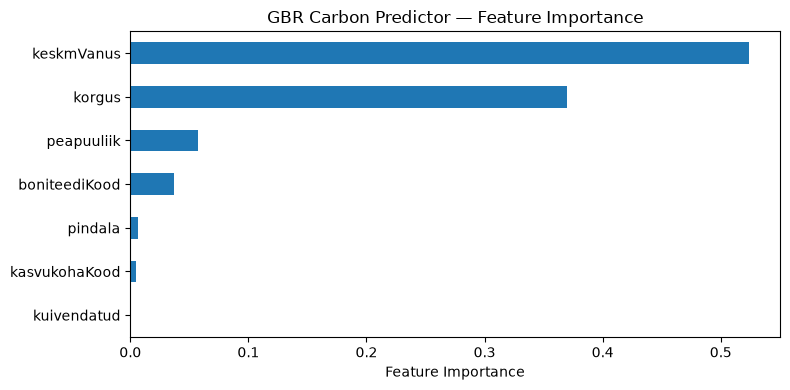

In [10]:
importances = pd.Series(model.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
importances.plot(kind="barh", ax=ax)
ax.set_xlabel("Feature Importance")
ax.set_title("GBR Carbon Predictor — Feature Importance")
plt.tight_layout()
plt.show()

## Predicted vs actual

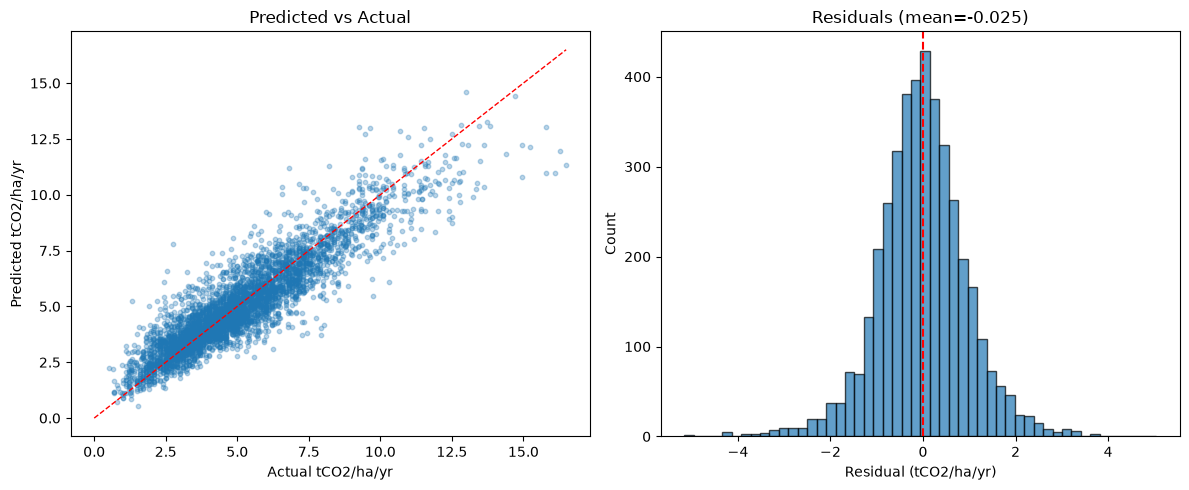

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.scatter(y_test, y_pred, alpha=0.3, s=10)
lims = [0, max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, "r--", lw=1)
ax.set_xlabel("Actual tCO2/ha/yr")
ax.set_ylabel("Predicted tCO2/ha/yr")
ax.set_title("Predicted vs Actual")

ax = axes[1]
residuals = y_pred - y_test
ax.hist(residuals, bins=50, edgecolor="black", alpha=0.7)
ax.axvline(0, color="red", linestyle="--")
ax.set_xlabel("Residual (tCO2/ha/yr)")
ax.set_ylabel("Count")
ax.set_title(f"Residuals (mean={residuals.mean():.3f})")

plt.tight_layout()
plt.show()

## Compare with NIR flat values

In [12]:
mae_mean = mean_absolute_error(y_test, np.full_like(y_test, y_test.mean()))
mae_nir = mean_absolute_error(y_test, np.full_like(y_test, 3.8))
mae_gbr = mean_absolute_error(y_test, y_pred)

print("Model comparison (MAE on test set):")
print(f"  Mean baseline:  {mae_mean:.3f} tCO2/ha/yr")
print(f"  NIR flat (3.8): {mae_nir:.3f} tCO2/ha/yr")
print(f"  GBR predictor:  {mae_gbr:.3f} tCO2/ha/yr")
print(f"\n  GBR improvement over NIR flat: {(1 - mae_gbr/mae_nir)*100:.0f}%")

Model comparison (MAE on test set):
  Mean baseline:  1.803 tCO2/ha/yr
  NIR flat (3.8): 1.995 tCO2/ha/yr
  GBR predictor:  0.727 tCO2/ha/yr

  GBR improvement over NIR flat: 64%


## Breakdown by species

In [13]:
species_map = {
    "MA": "Mänd (Pine)", "KU": "Kuusk (Spruce)", "KS": "Kask (Birch)",
    "HB": "Haab (Aspen)", "LM": "Must lepp (Black alder)",
    "LV": "Valge lepp (Grey alder)", "SA": "Saar (Ash)",
    "TA": "Tamm (Oak)",
}

print("Mean tCO2/ha/yr by species:")
by_species = df_valid.groupby("peapuuliik")["tco2_ha_yr"].agg(["mean", "count", "std"])
by_species = by_species[by_species["count"] >= 10].sort_values("mean", ascending=False)
for code, row in by_species.iterrows():
    name = species_map.get(code, code)
    print(f"  {name:25s}: {row['mean']:.2f} ± {row['std']:.2f} tCO2/ha/yr (n={int(row['count'])})")

Mean tCO2/ha/yr by species:
  Valge lepp (Grey alder)  : 6.73 ± 3.12 tCO2/ha/yr (n=1600)
  Kuusk (Spruce)           : 6.39 ± 2.50 tCO2/ha/yr (n=2692)
  Kask (Birch)             : 5.65 ± 2.39 tCO2/ha/yr (n=7770)
  Must lepp (Black alder)  : 5.37 ± 2.00 tCO2/ha/yr (n=1028)
  PN                       : 4.90 ± 2.27 tCO2/ha/yr (n=12)
  Saar (Ash)               : 4.61 ± 2.82 tCO2/ha/yr (n=86)
  Mänd (Pine)              : 4.42 ± 1.93 tCO2/ha/yr (n=7674)
  Haab (Aspen)             : 4.34 ± 2.21 tCO2/ha/yr (n=1433)
  RE                       : 4.21 ± 1.78 tCO2/ha/yr (n=15)
  VA                       : 3.91 ± 2.45 tCO2/ha/yr (n=13)
  PP                       : 3.40 ± 1.98 tCO2/ha/yr (n=12)
  Tamm (Oak)               : 3.30 ± 1.72 tCO2/ha/yr (n=184)


## Save model

In [14]:
import joblib

model_dir = Path("../data/processed/learned_carbon")
model_dir.mkdir(parents=True, exist_ok=True)
model_path = model_dir / "forest_carbon_gbr.joblib"
joblib.dump(model, model_path)
print(f"Model saved to {model_path}")

# Save training metadata
meta = {
    "features": FEATURE_COLS,
    "wood_densities": WOOD_DENSITY,
    "carbon_fraction": CARBON_FRACTION,
    "co2_per_c": CO2_PER_C,
    "bef": BEF,
    "train_size": len(X_train),
    "test_size": len(X_test),
    "r2": r2_score(y_test, y_pred),
    "mae": mean_absolute_error(y_test, y_pred),
    "target_mean": float(y.mean()),
    "target_std": float(y.std()),
    "sources": {
        "wood_density": "IPCC GPG-LULUCF Table 3A.1.9 — https://www.fao.org/4/j2132s/J2132S16.htm",
        "bef": "IPCC GPG-LULUCF Table 3A.1.10 — https://www.fao.org/3/j2132s/J2132S18.htm",
        "carbon_fraction": "IPCC 2006 Vol4 Ch4 Table 4.3; Estonian: Uri et al. 2017, 2019",
    },
}
pd.Series(meta).to_json(model_dir / "forest_carbon_gbr_meta.json")
print("Metadata saved")

Model saved to ..\data\processed\learned_carbon\forest_carbon_gbr.joblib
Metadata saved


## Next steps

1. Spatial join compartments → 1km grid (area-weighted features)
2. Integrate GBR into simulator as a third carbon model option
3. Compare evolution: flat vs NIR vs learned predictor